# Task 1: Service Time & Lateness Prediction

**Team BigBug — Tech Triathlon 2026 Datathon**

This notebook:
1. Loads training data and constructs labels
2. Engineers features using the `src/` modules
3. Trains LightGBM models for:
   - `pred_service_min` — regression (RMSE/MAE)
   - `pred_late_prob` — calibrated probability (ROC AUC / Brier Score)
4. Evaluates on a time-based holdout split
5. Generates `submission_task1.csv`

In [1]:
import sys
import os
from pathlib import Path

# Ensure project root is on the path
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\sithu\MyWorks\My Softwares\Competitions\Tech_Triathlon_26\TT_Datathon


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, brier_score_loss, log_loss,
    classification_report, confusion_matrix,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.7.0


## 1. Load Data & Construct Labels

In [3]:
from src.preprocessing import (
    load_deliveries_train,
    load_route_legs_train,
    load_task1_test_inputs,
    load_route_legs_test,
    load_submission_template,
    construct_labels,
    hhmm_to_minutes,
)

# Load raw data
deliveries_train = load_deliveries_train()
route_legs_train = load_route_legs_train()

print(f"Deliveries (train): {deliveries_train.shape}")
print(f"Route legs (train): {route_legs_train.shape}")

Deliveries (train): (92307, 20)
Route legs (train): (91894, 22)


In [4]:
# Construct labels
labeled = construct_labels(deliveries_train, route_legs_train, service_time_cap_min=180.0)

print(f"Labeled dataset shape: {labeled.shape}")
print(f"\nService time stats:")
print(labeled["service_time_min"].describe())
print(f"\nLate rate: {labeled['is_late'].mean():.4f} ({labeled['is_late'].sum()} / {len(labeled)})")
print(f"Early arrival rate: {labeled['arrived_early'].mean():.4f}")

Labeled dataset shape: (91894, 34)

Service time stats:
count    91894.000000
mean        19.855399
std         15.419728
min          2.000000
25%         11.000000
50%         16.000000
75%         23.000000
max        180.000000
Name: service_time_min, dtype: float64

Late rate: 0.1958 (17991 / 91894)
Early arrival rate: 0.0438


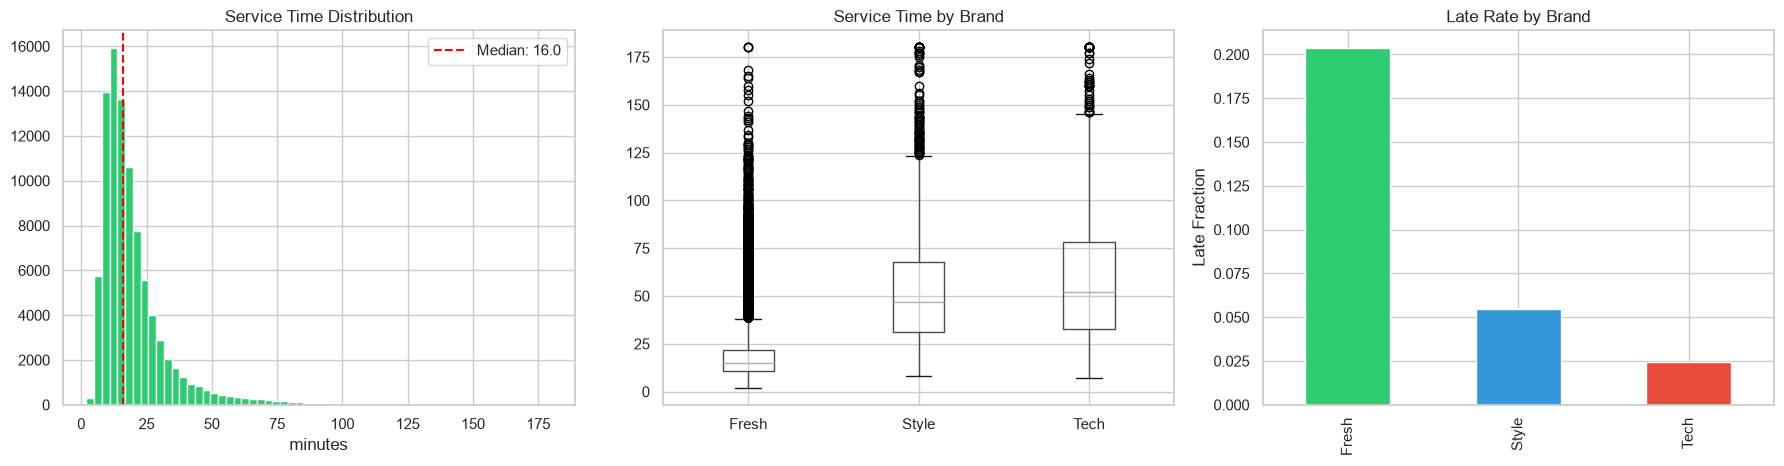

In [5]:
# Visualize label distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Service time distribution
labeled["service_time_min"].hist(bins=60, ax=axes[0], color="#2ecc71", edgecolor="white")
axes[0].set_title("Service Time Distribution")
axes[0].set_xlabel("minutes")
axes[0].axvline(labeled["service_time_min"].median(), color="red", ls="--",
                label=f"Median: {labeled['service_time_min'].median():.1f}")
axes[0].legend()

# Service time by brand
labeled.boxplot(column="service_time_min", by="brand", ax=axes[1])
axes[1].set_title("Service Time by Brand")
axes[1].set_xlabel("")
plt.sca(axes[1])
plt.suptitle("")

# Late rate by brand
labeled.groupby("brand")["is_late"].mean().plot.bar(
    ax=axes[2], color=["#2ecc71", "#3498db", "#e74c3c"]
)
axes[2].set_title("Late Rate by Brand")
axes[2].set_ylabel("Late Fraction")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [6]:
from src.features_task1 import (
    build_features,
    get_feature_columns,
    get_categorical_columns,
)

# Build features for training data
print("Building features (this may take a minute)...")
train_featured = build_features(labeled, route_legs_train, is_train=True)
print(f"Featured dataset shape: {train_featured.shape}")

Building features (this may take a minute)...
Featured dataset shape: (91894, 64)


In [7]:
# Verify all feature columns are present
feature_cols = get_feature_columns()
cat_cols = get_categorical_columns()

missing_num = [c for c in feature_cols if c not in train_featured.columns]
missing_cat = [c for c in cat_cols if c not in train_featured.columns]

if missing_num:
    print(f"⚠️  Missing numeric features: {missing_num}")
if missing_cat:
    print(f"⚠️  Missing categorical features: {missing_cat}")
if not missing_num and not missing_cat:
    print(f"✅ All {len(feature_cols)} numeric + {len(cat_cols)} categorical features present.")

# Check nulls in feature columns
available_feats = [c for c in feature_cols if c in train_featured.columns]
available_cats = [c for c in cat_cols if c in train_featured.columns]
all_model_cols = available_feats + available_cats

null_counts = train_featured[all_model_cols].isnull().sum()
null_cols = null_counts[null_counts > 0]
if len(null_cols) > 0:
    print(f"\nColumns with nulls:")
    print(null_cols)
else:
    print("No nulls in feature columns.")

✅ All 27 numeric + 10 categorical features present.
No nulls in feature columns.


## 3. Train / Validation Split

Use a **time-based split** — train on earlier data, validate on the last ~4 weeks.
This mimics the real scenario where we predict future deliveries.

In [8]:
# Time-based split: use order_date
train_featured["order_date"] = pd.to_datetime(train_featured["order_date"])
date_sorted = train_featured.sort_values("order_date")

# Find the cutoff: approximately last 4 weeks for validation
max_date = date_sorted["order_date"].max()
min_date = date_sorted["order_date"].min()
total_days = (max_date - min_date).days
cutoff_date = max_date - pd.Timedelta(days=28)

print(f"Date range: {min_date.date()} to {max_date.date()} ({total_days} days)")
print(f"Cutoff date: {cutoff_date.date()}")

train_mask = date_sorted["order_date"] < cutoff_date
val_mask = date_sorted["order_date"] >= cutoff_date

print(f"\nTrain rows: {train_mask.sum()} ({train_mask.mean()*100:.1f}%)")
print(f"Val rows:   {val_mask.sum()} ({val_mask.mean()*100:.1f}%)")

Date range: 2024-01-01 to 2026-02-14 (775 days)
Cutoff date: 2026-01-17

Train rows: 88395 (96.2%)
Val rows:   3499 (3.8%)


In [9]:
# Encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
df_model = date_sorted.copy()

for col in available_cats:
    le = LabelEncoder()
    # Fit on all data to handle unseen categories in test
    df_model[col] = df_model[col].fillna("__missing__")
    le.fit(df_model[col])
    df_model[col + "_enc"] = le.transform(df_model[col])
    label_encoders[col] = le

# Update feature column list with encoded versions
encoded_cat_cols = [c + "_enc" for c in available_cats]
model_features = available_feats + encoded_cat_cols

print(f"Total model features: {len(model_features)}")
print(f"Features: {model_features}")

Total model features: 37
Features: ['order_units', 'order_weight_kg', 'order_volume_m3', 'dow', 'is_payday', 'festival_ramp', 'is_holiday', 'monsoon', 'planned_arrival_minutes', 'planned_arrival_hour', 'window_duration_min', 'planned_slack_min', 'planned_vs_window_open_min', 'seq_in_route', 'total_stops', 'route_position_ratio', 'distance_km', 'route_total_weight', 'route_total_volume', 'route_total_units', 'depot_to_district_km', 'depot_to_district_freeflow_min', 'inter_stop_km', 'inter_stop_freeflow_min', 'service_allowance_min', 'speed_index', 'disruption_index', 'brand_enc', 'district_enc', 'depot_enc', 'vehicle_type_enc', 'vehicle_temp_enc', 'temp_requirement_enc', 'dock_type_enc', 'parking_constraint_enc', 'road_class_enc', 'dispatch_status_enc']


In [10]:
# Prepare X, y splits
X_train = df_model.loc[train_mask, model_features].copy()
X_val = df_model.loc[val_mask, model_features].copy()

y_train_service = df_model.loc[train_mask, "service_time_min"].copy()
y_val_service = df_model.loc[val_mask, "service_time_min"].copy()

y_train_late = df_model.loc[train_mask, "is_late"].copy()
y_val_late = df_model.loc[val_mask, "is_late"].copy()

# Fill NaN in features (LightGBM can handle NaN, but let's be safe)
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"\nTrain service time — mean: {y_train_service.mean():.2f}, std: {y_train_service.std():.2f}")
print(f"Val service time   — mean: {y_val_service.mean():.2f}, std: {y_val_service.std():.2f}")
print(f"\nTrain late rate: {y_train_late.mean():.4f}")
print(f"Val late rate:   {y_val_late.mean():.4f}")

X_train shape: (88395, 37)
X_val shape: (3499, 37)

Train service time — mean: 19.93, std: 15.49
Val service time   — mean: 17.88, std: 13.39

Train late rate: 0.1986
Val late rate:   0.1249


## 4. Model Training

### 4A. Service Time — LightGBM Regressor

In [11]:
# LightGBM Regressor for service time
lgb_reg_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "n_estimators": 1000,
    "random_state": 42,
    "verbose": -1,
}

lgb_train_reg = lgb.Dataset(X_train, y_train_service)
lgb_val_reg = lgb.Dataset(X_val, y_val_service, reference=lgb_train_reg)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]

model_service = lgb.train(
    lgb_reg_params,
    lgb_train_reg,
    valid_sets=[lgb_train_reg, lgb_val_reg],
    valid_names=["train", "val"],
    callbacks=callbacks,
)

print(f"\nBest iteration: {model_service.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 6.9989	val's rmse: 6.56926
[200]	train's rmse: 6.3637	val's rmse: 6.30205
[300]	train's rmse: 6.04569	val's rmse: 6.27341
[400]	train's rmse: 5.82139	val's rmse: 6.26215
[500]	train's rmse: 5.62459	val's rmse: 6.25182
Early stopping, best iteration is:
[488]	train's rmse: 5.6473	val's rmse: 6.24699

Best iteration: 488


In [12]:
# Evaluate service time model
pred_service_val = model_service.predict(X_val, num_iteration=model_service.best_iteration)
pred_service_train = model_service.predict(X_train, num_iteration=model_service.best_iteration)

# Clip to non-negative (service time can't be negative)
pred_service_val = np.clip(pred_service_val, 0, None)
pred_service_train = np.clip(pred_service_train, 0, None)

train_rmse = np.sqrt(mean_squared_error(y_train_service, pred_service_train))
val_rmse = np.sqrt(mean_squared_error(y_val_service, pred_service_val))
train_mae = mean_absolute_error(y_train_service, pred_service_train)
val_mae = mean_absolute_error(y_val_service, pred_service_val)
val_r2 = r2_score(y_val_service, pred_service_val)

print("=== Service Time Model ===")
print(f"Train RMSE: {train_rmse:.3f} | Val RMSE: {val_rmse:.3f}")
print(f"Train MAE:  {train_mae:.3f} | Val MAE:  {val_mae:.3f}")
print(f"Val R²: {val_r2:.4f}")

=== Service Time Model ===
Train RMSE: 5.648 | Val RMSE: 6.247
Train MAE:  3.930 | Val MAE:  3.918
Val R²: 0.7821


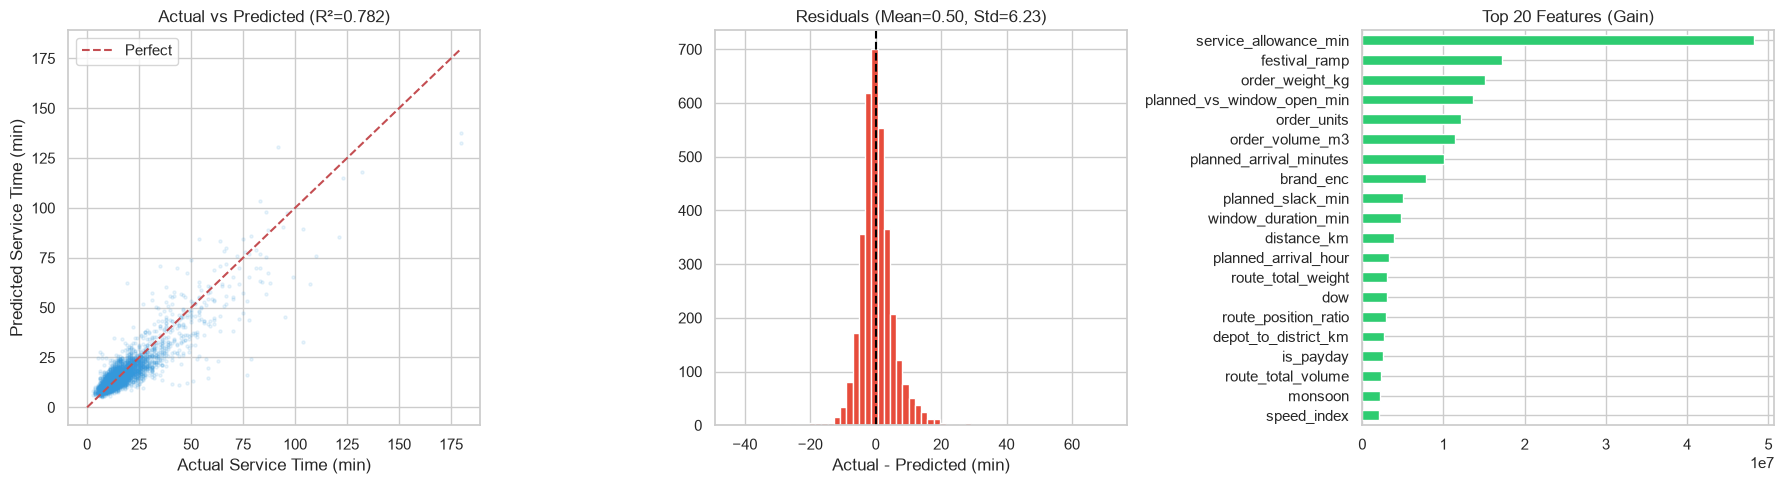

In [13]:
# Visualize service time predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs predicted scatter
axes[0].scatter(y_val_service, pred_service_val, alpha=0.1, s=5, color="#3498db")
max_val = max(y_val_service.max(), pred_service_val.max())
axes[0].plot([0, max_val], [0, max_val], "r--", lw=1.5, label="Perfect")
axes[0].set_xlabel("Actual Service Time (min)")
axes[0].set_ylabel("Predicted Service Time (min)")
axes[0].set_title(f"Actual vs Predicted (R²={val_r2:.3f})")
axes[0].legend()

# Residual distribution
residuals = y_val_service.values - pred_service_val
axes[1].hist(residuals, bins=60, color="#e74c3c", edgecolor="white")
axes[1].set_title(f"Residuals (Mean={residuals.mean():.2f}, Std={residuals.std():.2f})")
axes[1].set_xlabel("Actual - Predicted (min)")
axes[1].axvline(0, color="black", ls="--")

# Feature importance (top 20)
importance = pd.Series(
    model_service.feature_importance(importance_type="gain"),
    index=model_features
).sort_values(ascending=True)
importance.tail(20).plot.barh(ax=axes[2], color="#2ecc71")
axes[2].set_title("Top 20 Features (Gain)")

plt.tight_layout()
plt.show()

### 4B. Late Probability — LightGBM Classifier (Calibrated)

In [14]:
# LightGBM Classifier for lateness probability
lgb_clf_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "is_unbalance": True,
    "n_estimators": 1000,
    "random_state": 42,
    "verbose": -1,
}

lgb_train_clf = lgb.Dataset(X_train, y_train_late)
lgb_val_clf = lgb.Dataset(X_val, y_val_late, reference=lgb_train_clf)

callbacks_clf = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]

model_late = lgb.train(
    lgb_clf_params,
    lgb_train_clf,
    valid_sets=[lgb_train_clf, lgb_val_clf],
    valid_names=["train", "val"],
    callbacks=callbacks_clf,
)

print(f"\nBest iteration: {model_late.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.1918	val's binary_logloss: 0.1698
[200]	train's binary_logloss: 0.162606	val's binary_logloss: 0.157208
[300]	train's binary_logloss: 0.144633	val's binary_logloss: 0.154101
[400]	train's binary_logloss: 0.1301	val's binary_logloss: 0.151233
[500]	train's binary_logloss: 0.118611	val's binary_logloss: 0.149443
[600]	train's binary_logloss: 0.108617	val's binary_logloss: 0.148349
[700]	train's binary_logloss: 0.0998339	val's binary_logloss: 0.147323
Early stopping, best iteration is:
[680]	train's binary_logloss: 0.101494	val's binary_logloss: 0.147183

Best iteration: 680


In [15]:
# Evaluate lateness model
pred_late_val = model_late.predict(X_val, num_iteration=model_late.best_iteration)
pred_late_train = model_late.predict(X_train, num_iteration=model_late.best_iteration)

# Clip probabilities to [0, 1]
pred_late_val = np.clip(pred_late_val, 0, 1)
pred_late_train = np.clip(pred_late_train, 0, 1)

val_auc = roc_auc_score(y_val_late, pred_late_val)
val_brier = brier_score_loss(y_val_late, pred_late_val)
val_logloss = log_loss(y_val_late, pred_late_val)

train_auc = roc_auc_score(y_train_late, pred_late_train)

print("=== Lateness Probability Model ===")
print(f"Train ROC AUC: {train_auc:.4f} | Val ROC AUC: {val_auc:.4f}")
print(f"Val Brier Score: {val_brier:.4f} (lower is better)")
print(f"Val Log Loss:    {val_logloss:.4f}")

=== Lateness Probability Model ===
Train ROC AUC: 0.9966 | Val ROC AUC: 0.9738
Val Brier Score: 0.0475 (lower is better)
Val Log Loss:    0.1472


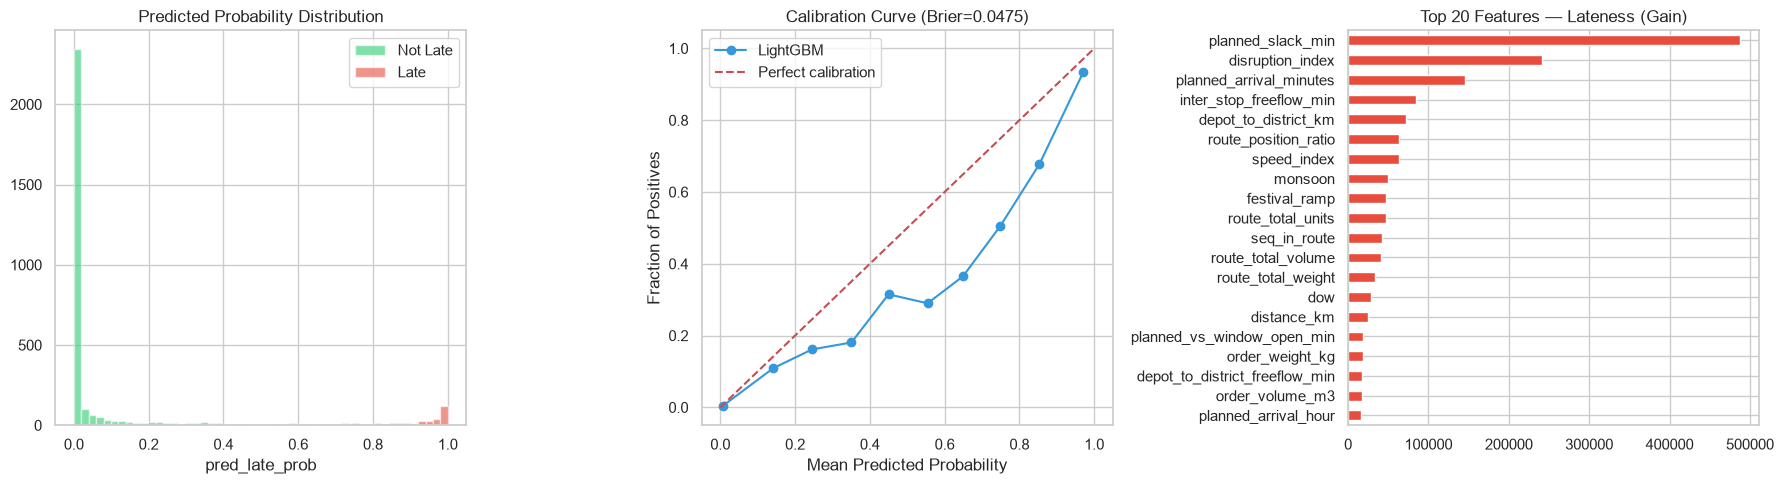

In [16]:
# Visualize lateness predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted probability distribution
axes[0].hist(pred_late_val[y_val_late == 0], bins=50, alpha=0.6, label="Not Late", color="#2ecc71")
axes[0].hist(pred_late_val[y_val_late == 1], bins=50, alpha=0.6, label="Late", color="#e74c3c")
axes[0].set_title("Predicted Probability Distribution")
axes[0].set_xlabel("pred_late_prob")
axes[0].legend()

# Calibration curve
prob_true, prob_pred = calibration_curve(y_val_late, pred_late_val, n_bins=10, strategy="uniform")
axes[1].plot(prob_pred, prob_true, marker="o", label="LightGBM", color="#3498db")
axes[1].plot([0, 1], [0, 1], "r--", label="Perfect calibration")
axes[1].set_title(f"Calibration Curve (Brier={val_brier:.4f})")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Fraction of Positives")
axes[1].legend()

# Feature importance (top 20)
importance_late = pd.Series(
    model_late.feature_importance(importance_type="gain"),
    index=model_features
).sort_values(ascending=True)
importance_late.tail(20).plot.barh(ax=axes[2], color="#e74c3c")
axes[2].set_title("Top 20 Features — Lateness (Gain)")

plt.tight_layout()
plt.show()

## 5. Calibration (Optional Improvement)

If the calibration curve shows the model is poorly calibrated, apply isotonic or Platt calibration.

Before calibration — Brier: 0.0475, AUC: 0.9738
After calibration  — Brier: 0.0400, AUC: 0.9750

Using calibration: True


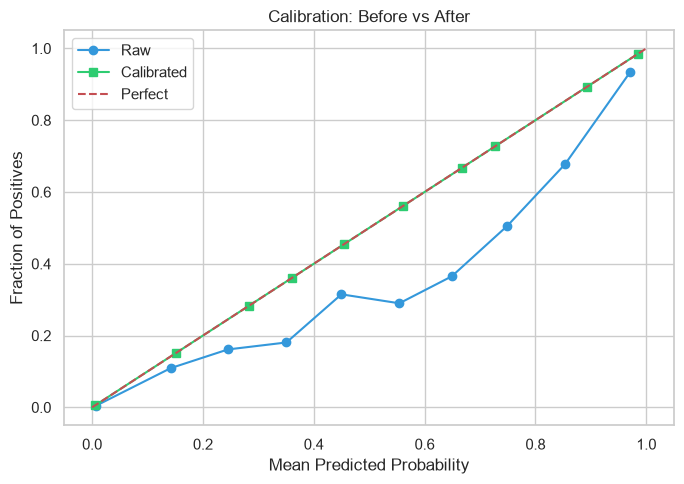

In [17]:
# Check if calibration is needed by examining the calibration curve
# If the curve deviates significantly from the diagonal, apply calibration

from sklearn.isotonic import IsotonicRegression

# Fit isotonic calibration on validation predictions
iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(pred_late_val, y_val_late)

# Apply calibration
pred_late_val_cal = iso_reg.predict(pred_late_val)
pred_late_val_cal = np.clip(pred_late_val_cal, 0, 1)

cal_brier = brier_score_loss(y_val_late, pred_late_val_cal)
cal_auc = roc_auc_score(y_val_late, pred_late_val_cal)

print(f"Before calibration — Brier: {val_brier:.4f}, AUC: {val_auc:.4f}")
print(f"After calibration  — Brier: {cal_brier:.4f}, AUC: {cal_auc:.4f}")

# Decide whether to use calibration
use_calibration = cal_brier < val_brier
print(f"\nUsing calibration: {use_calibration}")

if use_calibration:
    # Re-visualize calibration
    fig, ax = plt.subplots(figsize=(7, 5))
    prob_true_raw, prob_pred_raw = calibration_curve(y_val_late, pred_late_val, n_bins=10)
    prob_true_cal, prob_pred_cal = calibration_curve(y_val_late, pred_late_val_cal, n_bins=10)
    ax.plot(prob_pred_raw, prob_true_raw, marker="o", label="Raw", color="#3498db")
    ax.plot(prob_pred_cal, prob_true_cal, marker="s", label="Calibrated", color="#2ecc71")
    ax.plot([0, 1], [0, 1], "r--", label="Perfect")
    ax.set_title("Calibration: Before vs After")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Retrain on Full Training Data

Now retrain both models on the **entire** training set (no holdout) for the final submission.

In [18]:
# Retrain service time model on all training data
X_full = df_model[model_features].copy()
y_full_service = df_model["service_time_min"].copy()
y_full_late = df_model["is_late"].copy()

# Use best iteration from validation
best_iter_service = model_service.best_iteration
best_iter_late = model_late.best_iteration

print(f"Retraining with best iterations — Service: {best_iter_service}, Late: {best_iter_late}")

# Service time — retrain
lgb_reg_params_final = lgb_reg_params.copy()
lgb_reg_params_final["n_estimators"] = best_iter_service

lgb_full_reg = lgb.Dataset(X_full, y_full_service)
model_service_final = lgb.train(
    lgb_reg_params_final,
    lgb_full_reg,
    callbacks=[lgb.log_evaluation(period=200)],
)

# Lateness — retrain
lgb_clf_params_final = lgb_clf_params.copy()
lgb_clf_params_final["n_estimators"] = best_iter_late

lgb_full_clf = lgb.Dataset(X_full, y_full_late)
model_late_final = lgb.train(
    lgb_clf_params_final,
    lgb_full_clf,
    callbacks=[lgb.log_evaluation(period=200)],
)

print("Full retraining complete.")

Retraining with best iterations — Service: 488, Late: 680
Full retraining complete.


In [19]:
# If calibration helped, refit isotonic on full training predictions
if use_calibration:
    pred_late_full = model_late_final.predict(X_full)
    iso_reg_final = IsotonicRegression(out_of_bounds="clip")
    iso_reg_final.fit(pred_late_full, y_full_late)
    print("Isotonic calibration refitted on full training data.")
else:
    iso_reg_final = None
    print("No calibration applied.")

Isotonic calibration refitted on full training data.


## 7. Save Models

In [20]:
# Create models directory
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)

# Save LightGBM models
model_service_final.save_model(str(models_dir / "task1_service_time_lgb.txt"))
model_late_final.save_model(str(models_dir / "task1_late_prob_lgb.txt"))

# Save label encoders and calibrator
joblib.dump(label_encoders, models_dir / "task1_label_encoders.pkl")
if iso_reg_final is not None:
    joblib.dump(iso_reg_final, models_dir / "task1_isotonic_calibrator.pkl")

# Save feature column lists for reproducibility
joblib.dump({
    "model_features": model_features,
    "available_feats": available_feats,
    "available_cats": available_cats,
    "encoded_cat_cols": encoded_cat_cols,
    "use_calibration": use_calibration,
}, models_dir / "task1_feature_config.pkl")

print(f"Models saved to {models_dir}")
for f in models_dir.glob("task1_*"):
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

Models saved to c:\Users\sithu\MyWorks\My Softwares\Competitions\Tech_Triathlon_26\TT_Datathon\models
  task1_feature_config.pkl (1.0 KB)
  task1_isotonic_calibrator.pkl (2.7 KB)
  task1_label_encoders.pkl (2.8 KB)
  task1_late_prob_lgb.txt (4536.1 KB)
  task1_service_time_lgb.txt (2658.2 KB)


## 8. Generate Test Predictions & Submission

In [21]:
# Load test data
test_inputs = load_task1_test_inputs()
route_legs_test = load_route_legs_test()

print(f"Test inputs: {test_inputs.shape}")
print(f"Route legs test: {route_legs_test.shape}")

Test inputs: (5014, 20)
Route legs test: (5014, 18)


In [22]:
# Merge test deliveries with test route legs (same join as training)
test_merged = test_inputs.merge(
    route_legs_test[[
        "route_id", "seq",
        "distance_km", "from_point",
        "planned_depart_time", "planned_travel_duration_min",
    ]],
    left_on=["route_id", "seq_in_route"],
    right_on=["route_id", "seq"],
    how="inner",
)

# Add time columns that construct_labels would have added
test_merged["planned_arrival_minutes"] = hhmm_to_minutes(test_merged["planned_arrival_time"])
test_merged["window_open_minutes"] = hhmm_to_minutes(test_merged["window_open_time"])
test_merged["window_close_minutes"] = hhmm_to_minutes(test_merged["window_close_time"])

print(f"Test merged shape: {test_merged.shape}")
print(f"Successfully joined: {len(test_merged)} / {len(test_inputs)}")

Test merged shape: (5014, 28)
Successfully joined: 5014 / 5014


In [23]:
# Build features for test data
print("Building test features...")
test_featured = build_features(test_merged, route_legs_test, is_train=False)
print(f"Test featured shape: {test_featured.shape}")

Building test features...
Test featured shape: (5014, 58)


In [24]:
# Apply same label encoding to test data
test_model = test_featured.copy()

for col in available_cats:
    le = label_encoders[col]
    test_model[col] = test_model[col].fillna("__missing__")
    # Handle unseen categories
    known_classes = set(le.classes_)
    test_model[col] = test_model[col].apply(
        lambda x: x if x in known_classes else "__missing__"
    )
    # Re-fit if __missing__ wasn't in original classes
    if "__missing__" not in known_classes:
        le_classes = np.append(le.classes_, "__missing__")
        le.classes_ = le_classes
    test_model[col + "_enc"] = le.transform(test_model[col])

X_test = test_model[model_features].copy()
print(f"X_test shape: {X_test.shape}")

# Check for missing features
missing_test = [c for c in model_features if c not in X_test.columns]
if missing_test:
    print(f"⚠️  Missing features in test: {missing_test}")
else:
    print("✅ All features present in test data.")

X_test shape: (5014, 37)
✅ All features present in test data.


In [25]:
# Generate predictions
pred_service_test = model_service_final.predict(X_test)
pred_service_test = np.clip(pred_service_test, 0, None)  # No negative service times

pred_late_test = model_late_final.predict(X_test)
pred_late_test = np.clip(pred_late_test, 0, 1)

# Apply calibration if used
if use_calibration and iso_reg_final is not None:
    pred_late_test = iso_reg_final.predict(pred_late_test)
    pred_late_test = np.clip(pred_late_test, 0, 1)
    print("Isotonic calibration applied to test predictions.")

print(f"\nService time predictions — mean: {pred_service_test.mean():.2f}, std: {pred_service_test.std():.2f}")
print(f"Late probability predictions — mean: {pred_late_test.mean():.4f}, std: {pred_late_test.std():.4f}")
print(f"Late prob range: [{pred_late_test.min():.4f}, {pred_late_test.max():.4f}]")

Isotonic calibration applied to test predictions.

Service time predictions — mean: 19.14, std: 12.16
Late probability predictions — mean: 0.2130, std: 0.3792
Late prob range: [0.0000, 1.0000]


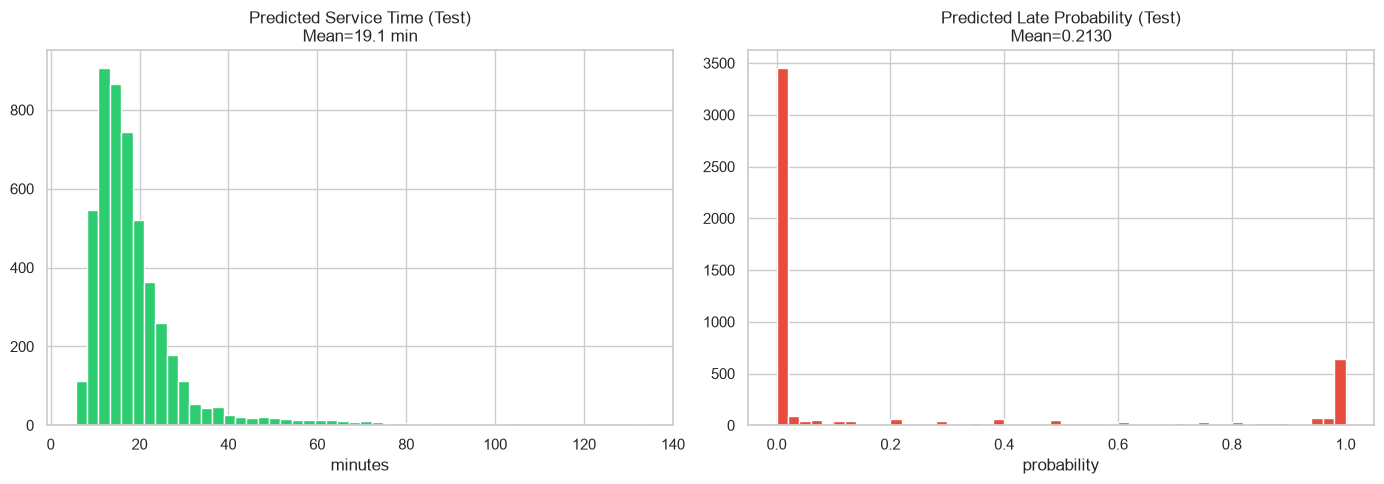

In [26]:
# Visualize test predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_service_test, bins=50, color="#2ecc71", edgecolor="white")
axes[0].set_title(f"Predicted Service Time (Test)\nMean={pred_service_test.mean():.1f} min")
axes[0].set_xlabel("minutes")

axes[1].hist(pred_late_test, bins=50, color="#e74c3c", edgecolor="white")
axes[1].set_title(f"Predicted Late Probability (Test)\nMean={pred_late_test.mean():.4f}")
axes[1].set_xlabel("probability")

plt.tight_layout()
plt.show()

In [27]:
# Create submission file
submission_template = load_submission_template("task1")
print(f"Submission template shape: {submission_template.shape}")
print(f"Template columns: {list(submission_template.columns)}")

# Map predictions back to delivery_ids preserving the template order
test_predictions = test_model[["delivery_id"]].copy()
test_predictions["pred_service_min"] = pred_service_test
test_predictions["pred_late_prob"] = pred_late_test

# Merge with template to preserve exact row order
submission = submission_template[["delivery_id"]].merge(
    test_predictions,
    on="delivery_id",
    how="left",
)

# Verify no missing predictions
missing_preds = submission["pred_service_min"].isna().sum()
if missing_preds > 0:
    print(f"⚠️  {missing_preds} delivery_ids have no prediction!")
    # Fill with reasonable defaults (median of training)
    submission["pred_service_min"].fillna(y_full_service.median(), inplace=True)
    submission["pred_late_prob"].fillna(y_full_late.mean(), inplace=True)
    print(f"Filled with training medians/means.")
else:
    print("✅ All delivery_ids have predictions.")

# Verify row count and order match
assert len(submission) == len(submission_template), "Row count mismatch!"
assert (submission["delivery_id"] == submission_template["delivery_id"]).all(), "Row order mismatch!"
print(f"✅ Row count ({len(submission)}) and order verified.")

Submission template shape: (5014, 3)
Template columns: ['delivery_id', 'pred_service_min', 'pred_late_prob']
✅ All delivery_ids have predictions.
✅ Row count (5014) and order verified.


In [28]:
# Round predictions for cleaner output
submission["pred_service_min"] = submission["pred_service_min"].round(2)
submission["pred_late_prob"] = submission["pred_late_prob"].round(4)

# Save submission
submission_path = PROJECT_ROOT / "data" / "raw" / "Submission Templates" / "submission_task1.csv"
submission.to_csv(submission_path, index=False)

print(f"\n✅ Submission saved to: {submission_path}")
print(f"Shape: {submission.shape}")
print(f"\nFirst 10 rows:")
submission.head(10)


✅ Submission saved to: c:\Users\sithu\MyWorks\My Softwares\Competitions\Tech_Triathlon_26\TT_Datathon\data\raw\Submission Templates\submission_task1.csv
Shape: (5014, 3)

First 10 rows:


,delivery_id,pred_service_min,pred_late_prob
0,ORD0092308,8.22,0.0000
1,ORD0092309,8.18,0.0000
2,ORD0092310,11.65,0.0000
3,ORD0092311,12.51,0.0000
4,ORD0092312,13.93,0.0000
5,ORD0092313,14.69,0.0000
6,ORD0092314,16.68,0.0000
7,ORD0092315,25.24,0.9415
8,ORD0092316,19.95,0.0000
9,ORD0092317,12.38,0.0000


In [29]:
# Final summary
print("=" * 60)
print("TASK 1 — SUMMARY")
print("=" * 60)
print(f"\nTraining data: {len(df_model)} labeled deliveries")
print(f"Test data: {len(test_inputs)} deliveries")
print(f"Model features: {len(model_features)}")
print(f"\n--- Service Time (Regression) ---")
print(f"Val RMSE: {val_rmse:.3f}  |  Val MAE: {val_mae:.3f}  |  Val R²: {val_r2:.4f}")
print(f"\n--- Late Probability (Classification → Probability) ---")
print(f"Val ROC AUC: {val_auc:.4f}  |  Val Brier: {val_brier:.4f}  |  Val LogLoss: {val_logloss:.4f}")
if use_calibration:
    print(f"Calibrated Brier: {cal_brier:.4f}")
print(f"\nCalibration applied: {use_calibration}")
print(f"Best iterations — Service: {best_iter_service}, Late: {best_iter_late}")
print(f"\nSubmission file: {submission_path}")
print(f"Models saved to: {models_dir}")
print("=" * 60)

TASK 1 — SUMMARY

Training data: 91894 labeled deliveries
Test data: 5014 deliveries
Model features: 37

--- Service Time (Regression) ---
Val RMSE: 6.247  |  Val MAE: 3.918  |  Val R²: 0.7821

--- Late Probability (Classification → Probability) ---
Val ROC AUC: 0.9738  |  Val Brier: 0.0475  |  Val LogLoss: 0.1472
Calibrated Brier: 0.0400

Calibration applied: True
Best iterations — Service: 488, Late: 680

Submission file: c:\Users\sithu\MyWorks\My Softwares\Competitions\Tech_Triathlon_26\TT_Datathon\data\raw\Submission Templates\submission_task1.csv
Models saved to: c:\Users\sithu\MyWorks\My Softwares\Competitions\Tech_Triathlon_26\TT_Datathon\models
